# Verificación de hallazgos — Fase A, semana 1Este notebook trabaja con los datos crudos, paso a paso, para responder a trespreguntas:1. **¿En qué huso horario están los timestamps de InfluxDB?** Se demuestra con la   posición del sol que están en **UTC**, no en hora local.2. **¿A qué hora se ejecutó realmente el ensayo de SHADE?** Según el log del   actuador, de **14:05 a 17:59 hora local**, no a las 08:00 como pedía el   protocolo.3. **¿Qué hay que repetir del solapamiento FOG / RECIRC del 6 de agosto?**> **Restricciones**: el límite de seguridad está en **50 °C** porque por encima se> pueden dañar los equipos, y en agosto **no es posible una línea base pasiva> limpia** en horas centrales. Se tratan como restricciones físicas del sistema,> no como incidencias.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA = 'climate devices experiments data'
plt.rcParams['figure.figsize'] = (13, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---

## 0. Lectores

Tres lectores, deliberadamente distintos:

- `read_raw()` — índice **exactamente como viene del CSV**, sin desplazar. Es el
  que se usa para *demostrar* en qué huso están los datos.
- `read_local()` — aplica `+2 h` (UTC → CEST). Sólo se usa **después** de haberlo
  demostrado.
- `read_actuator_local()` — actuadores: mantiene el último estado conocido.

**Ojo con el FOG:** su controlador usa `-15` como código de apagado y `1` como
encendido, pulsando dentro de cada minuto. El patrón habitual del proyecto
(`clip(lower=0)` + `resample().last()`) lo deja **todo a cero**, porque el último
estado de cada minuto casi siempre es el `-15` del apagado. Necesita su propio
lector, que **integra el ciclo de trabajo** (`read_fog_duty`).

In [4]:
def read_raw(name):
    """Serie a 1 min con el indice TAL CUAL viene del CSV (sin desplazar)."""
    df = pd.read_csv(f'{DATA}/{name}_0.csv')
    df['_time'] = pd.to_datetime(df['_time'], format='mixed', utc=True).dt.tz_localize(None)
    df = df.sort_values('_time').drop_duplicates('_time')
    return df.set_index('_time')['_value'].resample('min').mean()

def read_local(name):
    """Igual, pero desplazado a hora local peninsular de verano (CEST = UTC+2)."""
    s = read_raw(name)
    s.index = s.index + pd.Timedelta(hours=2)
    return s

def read_actuator_local(name):
    """Actuador de estado sostenido (ventanas, pantalla, recirculadores)."""
    df = pd.read_csv(f'{DATA}/{name}_0.csv')
    df['_time'] = pd.to_datetime(df['_time'], format='mixed', utc=True).dt.tz_localize(None)
    df['_value'] = df['_value'].clip(lower=0)      # -2 espurio de Calefactores -> 0
    df = df.sort_values('_time').drop_duplicates('_time')
    s = df.set_index('_time')['_value'].resample('min').last().ffill()
    s.index = s.index + pd.Timedelta(hours=2)
    return s

def read_fog_duty(name='Fog'):
    """FOG: pulsa dentro de cada minuto (-15 = apagado, 1 = encendido).

    Devuelve SEGUNDOS ENCENDIDO POR MINUTO integrando la funcion escalon.
    No usar read_actuator_local() aqui: devolveria todo ceros."""
    df = pd.read_csv(f'{DATA}/{name}_0.csv')
    df['_time'] = pd.to_datetime(df['_time'], format='mixed', utc=True).dt.tz_localize(None)
    df = df.sort_values('_time').drop_duplicates('_time')
    df['on'] = (df['_value'] == 1).astype(int)
    seg = pd.date_range(df['_time'].min().floor('min'),
                        df['_time'].max().ceil('min'), freq='s')
    estado = df.set_index('_time')['on'].reindex(seg, method='ffill').fillna(0)
    duty = estado.resample('min').mean() * 60      # segundos ON por minuto
    duty.index = duty.index + pd.Timedelta(hours=2)
    return duty

---

# 1. ¿Por qué sabemos que los datos están en UTC?


## 1.1 Prueba A — primera luz en el índice crudo

In [5]:
rad_raw = read_raw('Radiación_Solar_Global_Interior_(W_m_-2)')
par_raw = read_raw('PAR_interior_(µmol_m_-2_s_-1)')

print('Indice CRUDO del CSV (sin ningun desplazamiento aplicado)')
print(f'  rango: {rad_raw.index.min()}  ->  {rad_raw.index.max()}\n')
print(f"{'dia':12} {'1a luz (RAD)':>13} {'1a luz (PAR)':>13} {'ultima luz':>12}")
for day, g in rad_raw.groupby(rad_raw.index.date):
    on = g[g > 5]
    gp = par_raw[par_raw.index.date == day]
    onp = gp[gp > 5]
    if len(on) < 20:
        continue
    print(f'{str(day):12} {on.index.min().strftime("%H:%M"):>13} '
          f'{onp.index.min().strftime("%H:%M"):>13} {on.index.max().strftime("%H:%M"):>12}')

Indice CRUDO del CSV (sin ningun desplazamiento aplicado)
  rango: 2026-08-03 00:00:00  ->  2026-08-07 09:24:00

dia           1a luz (RAD)  1a luz (PAR)   ultima luz
2026-08-03           05:17         05:10        19:05
2026-08-04           05:20         05:12        19:01
2026-08-05           05:20         05:12        18:58
2026-08-06           05:24         05:14        19:08
2026-08-07           05:21         05:14        09:24


In [ ]:
# LOS DATOS EN CRUDO, minuto a minuto — para VER el amanecer, no solo el resumen.
# El indice NO lleva ningun desplazamiento: es tal cual sale del CSV.
dia = '2026-08-05'

print('AMANECER — valores crudos minuto a minuto (indice SIN desplazar)\n')
print(f"{'hora':>6} {'RAD (W/m2)':>11} {'PAR':>8}")
for t in pd.date_range(f'{dia} 04:55', f'{dia} 05:30', freq='min'):
    marca = ''
    if rad_raw[t] > 5 >= rad_raw[t - pd.Timedelta(minutes=1)]:
        marca += '   <-- RAD cruza 5'
    if par_raw[t] > 5 >= par_raw[t - pd.Timedelta(minutes=1)]:
        marca += '   <-- PAR cruza 5'
    print(f'{t.strftime("%H:%M"):>6} {rad_raw[t]:11.2f} {par_raw[t]:8.2f}{marca}')


AMANECER — valores crudos minuto a minuto (indice SIN desplazar)

  hora  RAD (W/m2)      PAR
 04:55        0.36     0.23
 04:56        0.42     0.56
 04:57        0.45     0.48
 04:58        0.55     0.64
 04:59        0.62     0.84
 05:00        0.69     1.06
 05:01        0.79     1.36
 05:02        0.91     1.49
 05:03        1.00     1.72
 05:04        1.10     2.02
 05:05        1.22     2.44
 05:06        1.39     2.79
 05:07        1.51     3.14
 05:08        1.67     3.38
 05:09        1.81     3.69
 05:10        1.98     4.37
 05:11        2.25     4.67
 05:12        2.45     5.22   <-- PAR cruza 5
 05:13        2.71     5.78
 05:14        2.95     6.50
 05:15        3.31     7.13
 05:16        3.56     7.88
 05:17        3.92     8.41
 05:18        4.01     9.18
 05:19        4.67     9.75
 05:20        5.40    10.84   <-- RAD cruza 5
 05:21        5.74    11.67
 05:22        5.93    12.46
 05:23        7.41    14.36
 05:24        7.86    15.20
 05:25        7.80    15.49
 0

In [7]:
# LA COMPARACION QUE ZANJA EL ASUNTO
# En Murcia, a primeros de agosto, el sol sale poco despues de las 07:00 LOCAL.
# Si el indice crudo estuviese en hora local, a las 07:00 deberia estar amaneciendo
# (valores cerca de cero). Veamos que hay realmente a esa hora del indice crudo.

print('a) NOCHE PROFUNDA del indice crudo (02:00) — control, aqui NO puede haber luz')
for t in pd.date_range(f'{dia} 02:00', f'{dia} 02:04', freq='min'):
    print(f'     {t.strftime("%H:%M")}   RAD={rad_raw[t]:7.2f}   PAR={par_raw[t]:7.2f}')
print('     (valores ~0 o levemente negativos: es el cero del sensor)')

print('\nb) LAS 07:00 del indice crudo — si fuese hora local, el sol estaria saliendo AHORA')
for t in pd.date_range(f'{dia} 07:00', f'{dia} 07:20', freq='5min'):
    print(f'     {t.strftime("%H:%M")}   RAD={rad_raw[t]:7.1f}   PAR={par_raw[t]:7.1f}')

print('\n' + '='*72)
print('A las 07:00 del indice crudo el PAR ya vale ~180-240, no cero.')
print('El sol lleva casi 2 h fuera. Luego ese "07:00" NO es la hora local:')
print('corresponde a las 09:00 locales. El indice esta en UTC.')
print('='*72)

a) NOCHE PROFUNDA del indice crudo (02:00) — control, aqui NO puede haber luz
     02:00   RAD=   0.02   PAR=  -0.23
     02:01   RAD=   0.04   PAR=  -0.19
     02:02   RAD=   0.04   PAR=  -0.29
     02:03   RAD=   0.04   PAR=  -0.27
     02:04   RAD=   0.04   PAR=  -0.13
     (valores ~0 o levemente negativos: es el cero del sensor)

b) LAS 07:00 del indice crudo — si fuese hora local, el sol estaria saliendo AHORA
     07:00   RAD=   79.9   PAR=  176.6
     07:05   RAD=  105.4   PAR=  213.7
     07:10   RAD=  117.6   PAR=  236.9
     07:15   RAD=  107.6   PAR=  215.5
     07:20   RAD=  107.8   PAR=  219.8

A las 07:00 del indice crudo el PAR ya vale ~180-240, no cero.
El sol lleva casi 2 h fuera. Luego ese "07:00" NO es la hora local:
corresponde a las 09:00 locales. El indice esta en UTC.


En los datos crudos se ve el amanecer real: los sensores suben de forma continua
desde ~04:55 y cruzan el umbral de 5 hacia las **05:12–05:20**. No es un salto de
encendido, es la curva del sol.

Y la comparación de la última celda es la que zanja el asunto:

| Hora del índice crudo | PAR medido | Qué implicaría si el índice fuese hora local |
|---|---|---|
| 02:00 | ≈ 0 (ruido del sensor) | noche — coherente |
| **07:00** | **≈ 180–240** | el sol debería estar *saliendo*, no llevar 2 h fuera |

En Murcia, a primeros de agosto, el sol sale poco después de las **07:00 local**.
Como a las "07:00" del índice ya hay pleno día, ese 07:00 no puede ser hora local:
corresponde a las **09:00 locales**. El índice está en **UTC**.



## 1.2 Prueba B — el mediodía solar
Ésta prueba usa el
**punto medio entre primera y última luz**, que es simétrico y apenas se mueve.
El mediodía solar en Murcia es **12:11 UTC**, casi constante toda la semana.

In [8]:
LAT, LON = 38.0236, -1.1743   # UMU, Espinardo (Murcia)

def solar_events_utc(date, lat=LAT, lon=LON):
    """Algoritmo NOAA -> (amanecer, mediodia solar, ocaso) en horas decimales UTC."""
    n = pd.Timestamp(date).dayofyear
    gamma = 2*np.pi/365 * (n - 1 + 0.5)
    eqtime = 229.18*(0.000075 + 0.001868*np.cos(gamma) - 0.032077*np.sin(gamma)
                     - 0.014615*np.cos(2*gamma) - 0.040849*np.sin(2*gamma))
    decl = (0.006918 - 0.399912*np.cos(gamma) + 0.070257*np.sin(gamma)
            - 0.006758*np.cos(2*gamma) + 0.000907*np.sin(2*gamma)
            - 0.002697*np.cos(3*gamma) + 0.00148*np.sin(3*gamma))
    lat_r = np.radians(lat)
    cos_ha = (np.cos(np.radians(90.833))/(np.cos(lat_r)*np.cos(decl))
              - np.tan(lat_r)*np.tan(decl))
    ha = np.degrees(np.arccos(cos_ha))
    return ((720 - 4*(lon + ha) - eqtime)/60,
            (720 - 4*lon - eqtime)/60,
            (720 - 4*(lon - ha) - eqtime)/60)

def hhmm(h):
    h = h % 24
    return f'{int(h):02d}:{int(round((h - int(h))*60)):02d}'


print('Punto medio del dia luminoso, calculado sobre el INDICE CRUDO\n')
print(f"{'dia':12} {'1a luz':>8} {'ult. luz':>9} {'PUNTO MEDIO':>13} {'horas de luz':>13}")
mids = []
for day, g in par_raw.groupby(par_raw.index.date):
    on = g[g > 5]
    # exige un dia COMPLETO: al menos 10 h de luz (descarta el 7-ago, truncado)
    if len(on) < 60 or (on.index.max() - on.index.min()) < pd.Timedelta(hours=10):
        print(f'{str(day):12} {"(dia incompleto, se descarta)":>48}')
        continue
    a, b = on.index.min(), on.index.max()
    mid = a + (b - a)/2
    mids.append(mid.hour + mid.minute/60)
    print(f'{str(day):12} {a.strftime("%H:%M"):>8} {b.strftime("%H:%M"):>9} '
          f'{mid.strftime("%H:%M"):>13} {str(b - a):>13}')

noon_astro = solar_events_utc('2026-08-05')[1]
print(f'\n  Punto medio medido (media de {len(mids)} dias completos): {hhmm(np.mean(mids))}  <- indice crudo')
print(f'  Mediodia solar astronomico UTC                    : {hhmm(noon_astro)}')
print(f'  Mediodia solar astronomico CEST                   : {hhmm(noon_astro + 2)}')
print(f'\n  Error si el indice fuese UTC        : {abs(np.mean(mids) - noon_astro)*60:5.1f} min')
print(f'  Error si el indice fuese hora local: {abs(np.mean(mids) - (noon_astro + 2))*60:5.1f} min')

Punto medio del dia luminoso, calculado sobre el INDICE CRUDO

dia            1a luz  ult. luz   PUNTO MEDIO  horas de luz
2026-08-03      05:10     19:10         12:10 0 days 14:00:00
2026-08-04      05:12     19:11         12:11 0 days 13:59:00
2026-08-05      05:12     19:09         12:10 0 days 13:57:00
2026-08-06      05:14     19:12         12:13 0 days 13:58:00
2026-08-07                      (dia incompleto, se descarta)

  Punto medio medido (media de 4 dias completos): 12:11  <- indice crudo
  Mediodia solar astronomico UTC                    : 12:11
  Mediodia solar astronomico CEST                   : 14:11

  Error si el indice fuese UTC        :   0.1 min
  Error si el indice fuese hora local: 119.9 min


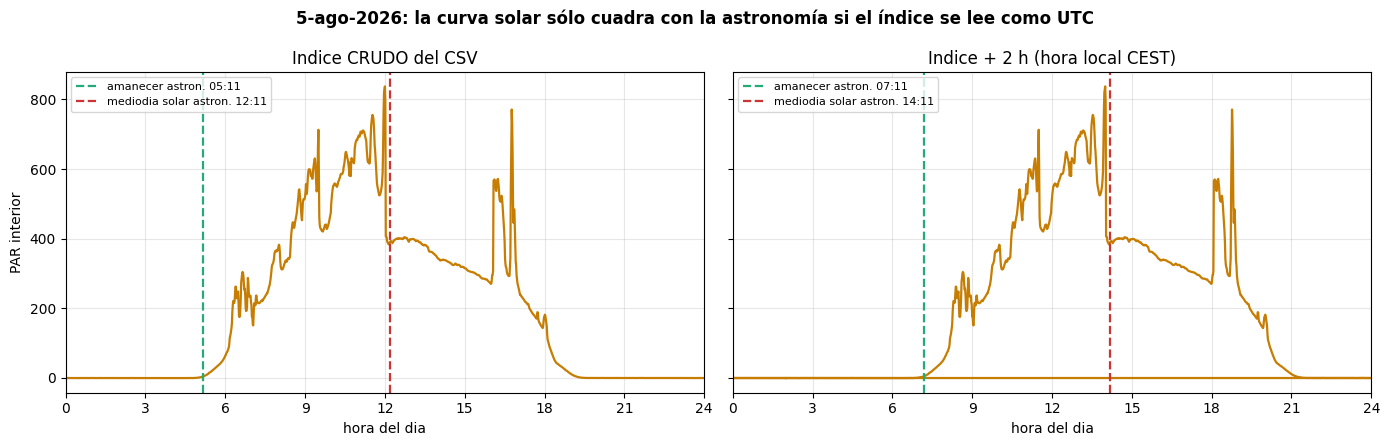

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

day = pd.Timestamp('2026-08-05')
raw_day = par_raw[par_raw.index.date == day.date()]
loc_day = raw_day.copy(); loc_day.index = loc_day.index + pd.Timedelta(hours=2)
sr, no, ss = solar_events_utc(day)

for ax, serie, etiqueta, noon_ref, sr_ref in [
        (ax1, raw_day, 'Indice CRUDO del CSV', no,     sr),
        (ax2, loc_day, 'Indice + 2 h (hora local CEST)', no + 2, sr + 2)]:
    ax.plot(serie.index.hour + serie.index.minute/60, serie.values, lw=1.6, color='#c77d02')
    ax.axvline(sr_ref,   color='#2a7', ls='--', lw=1.6, label=f'amanecer astron. {hhmm(sr_ref)}')
    ax.axvline(noon_ref, color='#c33', ls='--', lw=1.6, label=f'mediodia solar astron. {hhmm(noon_ref)}')
    ax.set_title(etiqueta); ax.set_xlabel('hora del dia'); ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 3)); ax.legend(fontsize=8, loc='upper left')

ax1.set_ylabel('PAR interior')
fig.suptitle('5-ago-2026: la curva solar sólo cuadra con la astronomía si el índice se lee como UTC',
             fontweight='bold')
plt.tight_layout(); plt.show()

**Conclusión del apartado 1.** El punto medio medido cae a **~12:11**, y el
mediodía solar astronómico es **12:11 UTC**. Error leyendo como UTC: **~1 minuto**.
Leyendo como hora local: **~120 minutos**.

En el panel izquierdo la curva es simétrica respecto al mediodía astronómico; en el
derecho está desplazada 2 h. Los CSV están en **UTC**: para hora local, `+2 h`.

Esto sostiene que **el controlador interpreta las reglas en UTC**, así
que una regla escrita "06:00" se ejecuta a las 08:00 local.

---

# 2. ¿Por qué sabemos que SHADE se ejecutó de 14:05 a 17:59?

No es una inferencia: está en el log del actuador. La única transformación aplicada
es el `+2 h`.

In [11]:
shade_raw = pd.read_csv(f'{DATA}/Pantalla_de_sombreo_cenital_0.csv')
print(f'Filas en el CSV: {len(shade_raw)}')
print('\nPrimeras y ultimas filas, TAL CUAL vienen del fichero (UTC):')
print(pd.concat([shade_raw.head(4), shade_raw.tail(4)]).to_string(index=False))

Filas en el CSV: 410

Primeras y ultimas filas, TAL CUAL vienen del fichero (UTC):
                   _time  _value
    2026-08-05T12:00:01Z       0
    2026-08-05T12:00:04Z       1
    2026-08-05T12:00:07Z       2
2026-08-05T12:00:09.604Z       0
2026-08-05T16:04:59.024Z       1
    2026-08-05T16:05:01Z       0
2026-08-05T16:05:11.709Z       0
2026-08-05T16:05:11.741Z       0


In [12]:
shade = read_actuator_local('Pantalla_de_sombreo_cenital')

# La pantalla tarda ~5 min en desplegarse (0 -> 100 en pasos de ~20 %).
# Se distingue el movimiento del tramo estable al 100 %.
desplegada = shade >= 99
bloques = (desplegada != desplegada.shift()).cumsum()

print('PANTALLA DE SOMBREO CENITAL — tramos al 100 % (hora LOCAL, CEST)\n')
for _, idx in shade.groupby(bloques).groups.items():
    if not desplegada[idx[0]] or len(idx) < 5:
        continue
    print(f'  {idx[0].strftime("%d-%b %H:%M")}  ->  {idx[-1].strftime("%H:%M")}   ({len(idx)} min al 100 %)')

print('\nPerfil de despliegue y repliegue (se ve la rampa del motor):')
print('  despliegue:', shade.loc['2026-08-05 13:59':'2026-08-05 14:05'].astype(int).tolist())
print('  repliegue :', shade.loc['2026-08-05 17:59':'2026-08-05 18:05'].astype(int).tolist())

print('\n  En UTC (como se introdujo la regla en el controlador):')
print(f'  {(pd.Timestamp("2026-08-05 14:05") - pd.Timedelta(hours=2)).strftime("%d-%b %H:%M")}'
      f'  ->  {(pd.Timestamp("2026-08-05 17:59") - pd.Timedelta(hours=2)).strftime("%H:%M")}')

PANTALLA DE SOMBREO CENITAL — tramos al 100 % (hora LOCAL, CEST)

  05-Aug 14:04  ->  17:59   (236 min al 100 %)

Perfil de despliegue y repliegue (se ve la rampa del motor):
  despliegue: [19, 39, 59, 79, 99, 100]
  repliegue : [100, 81, 61, 41, 21, 1, 0]

  En UTC (como se introdujo la regla en el controlador):
  05-Aug 12:05  ->  15:59


El log sitúa la pantalla al 100 % de **14:05 a 17:59 hora local** (12:05–15:59
UTC), con rampas de ~5 min a cada lado.

El protocolo pedía SHADE **a las 08:00 local**, para medir cuánto aplana la curva
de calentamiento *mientras la temperatura sube*. Se ejecutó seis horas más tarde.

## 2.1 El escalón sí es medible

La pantalla es el único actuador que se movió en esa franja, y el despliegue y el
repliegue son dos escalones limpios sobre la radiación interior.

In [13]:
Tc  = read_local('Temperatura_Interior_Centro_(ºC)')
RAD = read_local('Radiación_Solar_Global_Interior_(W_m_-2)')
PAR = read_local('PAR_interior_(µmol_m_-2_s_-1)')

def escalon(titulo, pre_ini, pre_fin, post_ini, post_fin):
    print(f'{titulo}')
    for lab, s in [('RAD interior', RAD), ('PAR interior', PAR), ('Temp. Centro', Tc)]:
        pre, post = s.loc[pre_ini:pre_fin].mean(), s.loc[post_ini:post_fin].mean()
        print(f'   {lab:13}: {pre:7.1f} -> {post:7.1f}   ({100*(post-pre)/pre:+6.1f} %)')
    print()

escalon('DESPLIEGUE  14:00 -> 14:04  (0 % -> 100 %)',
        '2026-08-05 13:45', '2026-08-05 13:59', '2026-08-05 14:06', '2026-08-05 14:20')
escalon('REPLIEGUE   18:00 -> 18:05  (100 % -> 0 %)',
        '2026-08-05 17:45', '2026-08-05 17:59', '2026-08-05 18:06', '2026-08-05 18:20')

DESPLIEGUE  14:00 -> 14:04  (0 % -> 100 %)
   RAD interior :   290.0 ->   212.0   ( -26.9 %)
   PAR interior :   603.3 ->   389.6   ( -35.4 %)
   Temp. Centro :    43.0 ->    45.1   (  +4.9 %)

REPLIEGUE   18:00 -> 18:05  (100 % -> 0 %)
   RAD interior :   150.5 ->   283.6   ( +88.5 %)
   PAR interior :   278.8 ->   549.4   ( +97.0 %)
   Temp. Centro :    47.5 ->    43.1   (  -9.3 %)



La pantalla **corta un 27 % de la radiación y un 35 % del PAR** al desplegarse, yal replegarse la radiación **se duplica** (+88 % RAD, +97 % PAR). El efecto ópticodel sombreo está medido.## 2.2 ¿Estaba el ensayo contaminado por las ventanas de seguridad?A esas horas el invernadero suele tocar el límite de 50 °C y las ventanas se abrensolas, así que conviene comprobar explícitamente si eso ocurrió durante el bloquede la pantalla:

In [14]:
ve = read_actuator_local('Ventana_cenital_este')
vn = read_actuator_local('Ventana_lateral_norte')

print('Aperturas de seguridad en la franja 14:05-17:59, por dia\n')
print(f"{'dia':12} {'Tc media':>9} {'Tc max':>7} {'RAD media':>10} {'aperturas':>10}")
for d in ['2026-08-03', '2026-08-04', '2026-08-05', '2026-08-06']:
    w = Tc.loc[f'{d} 14:05':f'{d} 17:59']
    r = RAD.loc[f'{d} 14:05':f'{d} 17:59']
    n_ap = 0
    for v in (ve, vn):
        s = v.loc[f'{d} 14:05':f'{d} 17:59']
        if s.empty:
            continue
        on = s > 2
        n_ap += (on & ~on.shift(fill_value=False)).sum()
    tag = '   <-- SHADE desplegada' if d == '2026-08-05' else ''
    print(f'{d:12} {w.mean():9.1f} {w.max():7.1f} {r.mean():10.0f} {n_ap:10d}{tag}')

print('\nOtros actuadores activos el 5-ago durante 14:05-17:59:')
for n in ['Ventana_cenital_este', 'Ventana_cenital_oeste', 'Ventana_lateral_norte',
          'Ventana_lateral_oeste', 'Ventana_lateral_sur']:
    s = read_actuator_local(n).loc['2026-08-05 14:05':'2026-08-05 17:59']
    print(f'   {n:24}: {(s > 2).sum():3d} min activo')
print('   Fog / Recirculador / Calefactores: sin datos ese dia (no se usaron)')

Aperturas de seguridad en la franja 14:05-17:59, por dia

dia           Tc media  Tc max  RAD media  aperturas
2026-08-03        44.1    50.0        140          2
2026-08-04        46.0    49.3        336          8
2026-08-05        47.4    48.5        189          0   <-- SHADE desplegada
2026-08-06        46.9    49.3        342          4

Otros actuadores activos el 5-ago durante 14:05-17:59:
   Ventana_cenital_este    :   0 min activo
   Ventana_cenital_oeste   :   0 min activo
   Ventana_lateral_norte   :   0 min activo
   Ventana_lateral_oeste   :   0 min activo
   Ventana_lateral_sur     :   0 min activo
   Fog / Recirculador / Calefactores: sin datos ese dia (no se usaron)


**El 5 de agosto tuvo CERO aperturas de seguridad** durante el bloque, frente a
2, 8 y 4 los otros días. Ningún otro actuador se movió. El ensayo de SHADE es el
**único bloque diurno limpio de toda la semana** — y precisamente porque la
pantalla evitó que el invernadero llegara al límite de 50 °C.

Es el resultado del día: fue el día con **el máximo más bajo** (48,5 °C frente a
49,3–50,0) pese a tener la **media más alta** (47,4 °C). La pantalla no baja la
temperatura media, pero **recorta el pico**, que es justo lo que hace falta para no
tocar el límite de seguridad.

Un matiz importante, y es la razón por la que el ensayo sigue sin ser
concluyente en cuanto a magnitud: el 5-ago tuvo **189 W/m² de radiación media**
frente a 336–342 de los días 4 y 6. Parte del pico más bajo es mérito de un día
menos radiante, no de la pantalla. La comparación entre días no permite separar
ambas cosas; los escalones del apartado 2.1, que son intra-día, sí.

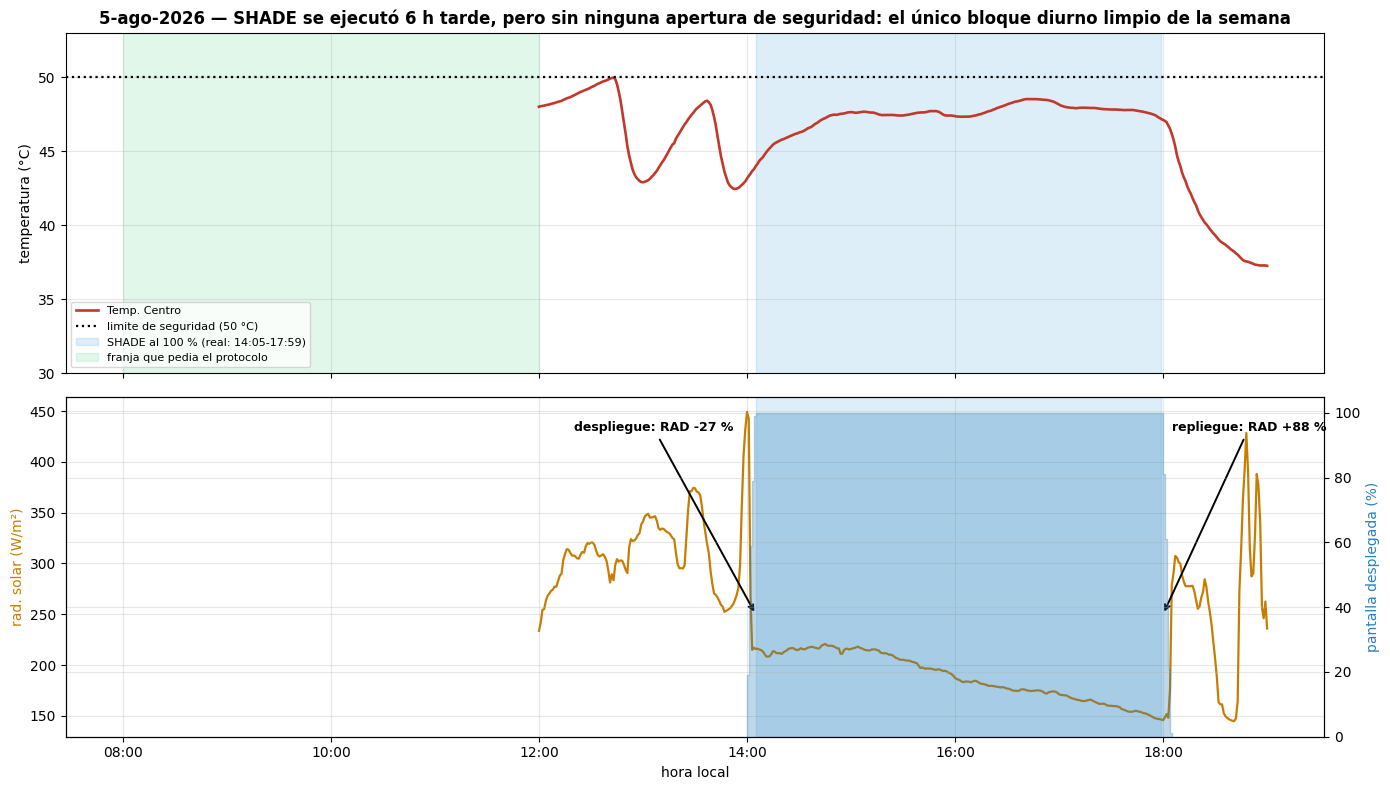

In [15]:
ini, fin = pd.Timestamp('2026-08-05 12:00'), pd.Timestamp('2026-08-05 19:00')
t, sh, r = Tc.loc[ini:fin], shade.loc[ini:fin], RAD.loc[ini:fin]

fig, (axA, axB) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axA.plot(t.index, t.values, color='#c0392b', lw=1.9, label='Temp. Centro')
axA.axhline(50, color='k', ls=':', lw=1.6, label='limite de seguridad (50 °C)')
axA.axvspan(pd.Timestamp('2026-08-05 14:05'), pd.Timestamp('2026-08-05 17:59'),
            color='#3498db', alpha=0.16, label='SHADE al 100 % (real: 14:05-17:59)')
axA.axvspan(pd.Timestamp('2026-08-05 08:00'), pd.Timestamp('2026-08-05 12:00'),
            color='#2ecc71', alpha=0.14, label='franja que pedia el protocolo')
axA.set_ylabel('temperatura (°C)'); axA.set_ylim(30, 53)
axA.legend(loc='lower left', fontsize=8)
axA.set_title('5-ago-2026 — SHADE se ejecutó 6 h tarde, pero sin ninguna apertura de '
              'seguridad: el único bloque diurno limpio de la semana', fontweight='bold')

axB.plot(r.index, r.values, color='#c77d02', lw=1.6, label='radiacion interior')
axB.axvspan(pd.Timestamp('2026-08-05 14:05'), pd.Timestamp('2026-08-05 17:59'),
            color='#3498db', alpha=0.16)
axB.set_ylabel('rad. solar (W/m²)', color='#c77d02')
axB2 = axB.twinx()
axB2.fill_between(sh.index, 0, sh.values, color='#2980b9', alpha=0.30, step='post')
axB2.set_ylabel('pantalla desplegada (%)', color='#2980b9'); axB2.set_ylim(0, 105)
axB.annotate('despliegue: RAD -27 %', xy=(pd.Timestamp('2026-08-05 14:05'), 250),
             xytext=(pd.Timestamp('2026-08-05 12:20'), 430), fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle='->', lw=1.4))
axB.annotate('repliegue: RAD +88 %', xy=(pd.Timestamp('2026-08-05 18:00'), 250),
             xytext=(pd.Timestamp('2026-08-05 18:05'), 430), fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle='->', lw=1.4))
axB.set_xlabel('hora local')
axB.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()

**Conclusión del apartado 2.** El log sitúa SHADE en **14:05–17:59 local**, seishoras después de lo previsto, por el desfase UTC.Aun así el bloque salió limpio: **no tuvo aperturas de seguridad ni ningún otroactuador activo**, y el efecto óptico está medido (−27 % RAD, −35 % PAR aldesplegar; +88 % / +97 % al replegar).**A6 conviene repetirlo a las 08:00**, no porque el dato esté contaminado, sinoporque a mediodía la pantalla actúa sobre un invernadero ya saturado de calor y nose puede medir *cuánto aplana la curva de calentamiento*, que era el objetivo. Eldato de 14:05–17:59 se conserva como medida válida del efecto óptico y del recortede pico.

---

# 3. FOG y RECIRC se solaparon: ¿qué hay que repetir?

Primero, el FOG necesita su propio lector. Se comprueba por qué.

In [ ]:
fog_mal  = read_actuator_local('Fog')       # patron habitual del proyecto
fog_duty = read_fog_duty()                 # integrando el ciclo de trabajo

print('Estados crudos en Fog_0.csv:')
print(' ', pd.read_csv(f'{DATA}/Fog_0.csv')['_value'].value_counts().to_dict())
print('   (-15 = apagado, 1 = encendido, 0 = transicion)\n')
print(f'read_actuator_local(): minutos con valor > 0 = {(fog_mal > 0).sum()}  <-- TODO CERO, incorrecto')
print(f'read_fog_duty()      : minutos con valor > 0 = {(fog_duty > 0).sum()}\n')
print(f'Ciclo medio medido: {fog_duty[fog_duty > 0].mean():.1f} s/min   (programado: 20 s/min)')
print(f'\nPrimeros 6 minutos (segundos ON por minuto):')
print(fog_duty.head(6).round(0).to_string())

Confirmado: el patrón habitual da **todo ceros** para el fog, porque el último
estado registrado dentro de cada minuto es casi siempre el apagado. Con la
integración correcta salen **~20 s/min**, exactamente lo programado.

*(Esto afecta también a `climateDevicesExperiments.ipynb`, que usa el patrón
habitual para todos los dispositivos.)*

Ahora, el solapamiento:

In [ ]:
recirc  = read_actuator_local('Recirculador')
recirc2 = read_actuator_local('Recirculador_centro')

def tramo(s, umbral=0):
    on = s > umbral
    return (on[on].index.min(), on[on].index.max()) if on.any() else None

for nombre, serie in [('FOG', fog_duty), ('RECIRC', recirc), ('RECIRC_centro', recirc2)]:
    a, b = tramo(serie)
    print(f'{nombre:15} {a.strftime("%d-%b %H:%M")} -> {b.strftime("%H:%M")} local'
          f'   ({int((b - a).total_seconds()/60) + 1} min)')

ini_ov = max(tramo(fog_duty)[0], tramo(recirc)[0])
fin_ov = min(tramo(fog_duty)[1], tramo(recirc)[1])
n_ov = int((fin_ov - ini_ov).total_seconds()/60) + 1
print(f'\nSOLAPAMIENTO: {ini_ov.strftime("%H:%M")} -> {fin_ov.strftime("%H:%M")}'
      f'  = {n_ov} min con AMBOS activos')

In [ ]:
HR  = read_local('Humedad_Relativa_interior_Centro_(%)')
Ta  = read_local('Temperatura_Interior_Alta_(ºC)')
Tb  = read_local('Temperatura_Interior_Baja_(ºC)')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
i0, i1 = pd.Timestamp('2026-08-06 05:30'), pd.Timestamp('2026-08-06 12:30')

def sombrear(ax):
    ax.axvspan(pd.Timestamp('2026-08-06 06:00'), pd.Timestamp('2026-08-06 08:00'),
               color='#2ecc71', alpha=0.18)
    ax.axvspan(pd.Timestamp('2026-08-06 08:00'), pd.Timestamp('2026-08-06 09:42'),
               color='#e74c3c', alpha=0.20)
    ax.axvspan(pd.Timestamp('2026-08-06 09:42'), pd.Timestamp('2026-08-06 12:00'),
               color='#f39c12', alpha=0.16)

ax = axes[0]
fd = fog_duty.loc[i0:i1]
ax.fill_between(fd.index, 0, fd.values, color='#2980b9', alpha=0.55, step='post', label='FOG (s/min)')
ax.set_ylabel('FOG (s ON/min)'); ax.set_ylim(0, 26)
axr = ax.twinx()
axr.step(recirc.loc[i0:i1].index, (recirc.loc[i0:i1] > 0).astype(int),
         where='post', color='#8e44ad', lw=2.0, label='RECIRC')
axr.set_ylim(-0.1, 1.6); axr.set_yticks([0, 1]); axr.set_yticklabels(['off', 'ON'])
sombrear(ax)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axr.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8)
ax.set_title('6-ago-2026 — verde: FOG solo (limpio) | rojo: SOLAPADO | naranja: RECIRC solo (confundido con el sol)',
             fontweight='bold')

ax = axes[1]
ax.plot(Tc.loc[i0:i1].index, Tc.loc[i0:i1].values, color='#c0392b', lw=1.8, label='Temp. Centro')
sombrear(ax); ax.set_ylabel('°C'); ax.legend(loc='upper left', fontsize=8)
axr = ax.twinx()
axr.plot(HR.loc[i0:i1].index, HR.loc[i0:i1].values, color='#16a085', lw=1.5, ls='--', label='HR')
axr.axhline(100, color='#16a085', ls=':', lw=1.2)
axr.set_ylabel('HR (%)'); axr.legend(loc='upper right', fontsize=8)

ax = axes[2]
ax.plot(RAD.loc[i0:i1].index, RAD.loc[i0:i1].values, color='#c77d02', lw=1.6)
sombrear(ax); ax.set_ylabel('rad. solar (W/m²)'); ax.set_xlabel('hora local')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()

In [ ]:
segmentos = [('FOG solo (limpio)',        '2026-08-06 06:00', '2026-08-06 07:59'),
             ('FOG + RECIRC (solapado)', '2026-08-06 08:00', '2026-08-06 09:42'),
             ('RECIRC solo',             '2026-08-06 09:43', '2026-08-06 11:59')]

filas = []
for lab, a, b in segmentos:
    t, h, r = Tc.loc[a:b], HR.loc[a:b], RAD.loc[a:b]
    est = (Ta - Tb).loc[a:b]
    filas.append({'segmento': lab, 'min': len(t),
                  'Tc ini': round(t.iloc[0], 1), 'Tc fin': round(t.iloc[-1], 1),
                  'dTc': round(t.iloc[-1] - t.iloc[0], 1),
                  'HR ini': round(h.iloc[0]), 'HR fin': round(h.iloc[-1]),
                  'estrat. sd': round(est.std(), 2),
                  'RAD media': round(r.mean())})
pd.DataFrame(filas)

## 3.1 Qué se salva y qué no

**FOG — se salva.** Los primeros **120 minutos (06:00–07:59)** el fog funcionó
**solo**, con RECIRC apagado y radiación prácticamente nula (6 W/m²). Dentro de ese
tramo limpio ocurre lo importante: **HR llegó al 100 % a las 07:42**. La conclusión
de que 20 s/min satura la humedad en madrugada se sostiene sin repetir el ensayo.

**RECIRC — no se salva.** Su tramo aislado (09:43–11:59) llega cuando la radiación
ya sube fuerte (189 W/m² de media) y Tc sube 13,7 °C en poco más de dos horas: ese
calentamiento es solar, no del recirculador. Además arranca con el invernadero
saturado de humedad por el fog previo, así que ni siquiera parte de un estado
neutro.

In [ ]:
print('QUE HAY QUE REPETIR')print('=' * 68)print("""  A9 / A10 — RECIRC y RECIRC_centro            [REPETIR]     Motivo : su unico tramo aislado (09:43-11:59) coincide con la subida solar              de la manana y arranca con el invernadero saturado por el fog              previo. El efecto de mezcla no se separa del calentamiento solar.     Cuando : DE NOCHE, 22:00-02:00 local  ->  programar 20:00 si el              controlador va en UTC. Sin deriva solar que contaminar, y la              estratificacion nocturna es mas marcada, asi que la senal es              mayor. La hora no es critica para medir mezcla.     Medir  : (Alta - Baja) y su DESVIACION TIPICA, no la temperatura media.              El recirculador homogeneiza; no refrigera.     Nota   : encenderlos en noches DISTINTAS resuelve ademas la pregunta              abierta (a) del protocolo (si conviene fusionarlos en un unico              grupo), porque hasta ahora se han movido siempre juntos.  A6 — SHADE (pantalla cenital)                [REPETIR, por otro motivo]     Motivo : el dato del 5-ago es limpio y sirve para el efecto optico              (-27 % radiacion), pero se ejecuto de 14:05 a 17:59 por el              desfase horario. A esa hora el invernadero ya esta en su maximo              de calor, asi que no se puede medir cuanto aplana la CURVA DE              CALENTAMIENTO, que era el objetivo del ensayo.     Cuando : 08:00-12:00 local (06:00 si el controlador va en UTC), con la              temperatura subiendo.  A7 — FOG a 20 s/min                          [NO hace falta repetir]     Motivo : 06:00-07:59 fue fog aislado, sin sol y con RECIRC apagado.              La saturacion de HR al 100 % (07:42) queda demostrada ahi.     Nota   : si se quiere el ensayo completo de 4 h sin corte por condensacion,              repetirlo a 10 s/min en vez de 20 s/min.""")print('=' * 68)print("""  PARA QUE NO SE REPITA EL SOLAPAMIENTO  1. Programar en UTC (hora local deseada - 2 h), si se confirma que el     controlador interpreta las reglas en ese huso.  2. Separar A7 y A9/A10 a dias distintos, o dejar margen suficiente de lavado     entre ellos.  3. Validar el programa ANTES de cargarlo: en Fase A no puede haber dos     grupos activos a la vez (comprobacion automatica en la celda siguiente).""")

## 3.2 Comprobación automática de solapamientos

Función reutilizable: conviene pasarla sobre el programa **antes** de cargarlo, y
sobre los datos recogidos para verificar que se ejecutó como se pretendía.

In [ ]:
# Cada grupo declara su propio umbral de "activo":
#   analogicos (ventanas, pantalla) van de 0 a 100  -> umbral 2 (ignora ruido)
#   binarios   (recirculadores, calefactores) valen 0/1 -> umbral 0
#
# Usar el mismo umbral 2 para todos era un ERROR: los binarios nunca lo superan,
# quedaban invisibles, y por eso el solapamiento FOG/RECIRC no se detectaba.
GRUPOS = {
    'VENT_ROOF': (['Ventana_cenital_este', 'Ventana_cenital_oeste'], 2),
    'VENT_SIDE': (['Ventana_lateral_norte', 'Ventana_lateral_oeste',
                   'Ventana_lateral_sur'], 2),
    'SHADE':     (['Pantalla_de_sombreo_cenital'], 2),
    'RECIRC':    (['Recirculador', 'Recirculador_centro'], 0),
    'RECIRC2':   (['Calefactores'], 0),
}   # FOG va aparte: necesita read_fog_duty()

def estado_grupos():
    """DataFrame a 1 min, un booleano por grupo (activo / no activo), hora local."""
    col = {}
    for grupo, (dispositivos, umbral) in GRUPOS.items():
        activo = None
        for d in dispositivos:
            try:
                s = read_actuator_local(d)
            except Exception:
                continue
            if s.empty:
                continue
            a = s > umbral
            if activo is None:
                activo = a
            else:
                idx = activo.index.union(a.index)
                activo = (activo.reindex(idx, fill_value=False)
                          | a.reindex(idx, fill_value=False))
        if activo is not None:
            col[grupo] = activo
    col['FOG'] = read_fog_duty() > 0

    idx = pd.date_range(min(s.index.min() for s in col.values()),
                        max(s.index.max() for s in col.values()), freq='min')
    df = pd.DataFrame({k: v.reindex(idx, fill_value=False) for k, v in col.items()})
    return df.fillna(False).astype(bool)

def buscar_solapamientos(df, min_minutos=5):
    """Tramos con 2 o mas grupos activos a la vez (prohibido en Fases A y B)."""
    solap = df.sum(axis=1) > 1
    bloques = (solap != solap.shift()).cumsum()
    out = []
    for _, idx in df.groupby(bloques).groups.items():
        if not solap[idx[0]] or len(idx) < min_minutos:
            continue
        grupos = [c for c in df.columns if df.loc[idx, c].any()]
        out.append({'inicio': idx[0], 'fin': idx[-1], 'min': len(idx),
                    'grupos': ' + '.join(grupos)})
    return pd.DataFrame(out)

estado = estado_grupos()
solapes = buscar_solapamientos(estado)
print('Solapamientos detectados en la semana 1 (>= 5 min, hora local):\n')
print(solapes.to_string(index=False) if len(solapes) else '  ninguno')

La comprobación devuelve **dos tipos** de solapamiento, que no son lo mismo:

- **`RECIRC + FOG`, 6-ago, 102 min** — el único solapamiento *de programa*: dos
  tratamientos de la Fase A pisándose. Es el que hay que evitar, y el que motiva
  repetir A9/A10.
- **`VENT_ROOF + VENT_SIDE`, 14 tramos de 11–41 min** — no son tratamientos: son
  las **aperturas de seguridad**, que mueven los dos grupos de ventanas a la vez
  al llegar a 50 °C. Son inevitables en agosto y no hay nada que corregir.

Al pasar esta función sobre el programa de la Fase B, sólo importa el primer tipo:
conviene filtrar los tramos que coincidan con disparos de seguridad, o
sencillamente ignorar las combinaciones `VENT_ROOF + VENT_SIDE` que aparezcan en
horas centrales sin estar programadas.

---# Resumen**1. Los datos están en UTC.** Dos pruebas independientes: la primera luz aparece alas 05:10–05:24 del índice crudo, y a las "07:00" de ese mismo índice ya hay plenodía (PAR ≈ 180–240), cuando en Murcia el sol sale poco después de las 07:00 local.El punto medio del día luminoso cae a las 12:11 frente al mediodía solarastronómico de 12:11 UTC: error leyendo como UTC **~1 min**; como hora local**~120 min**.**2. SHADE se ejecutó de 14:05 a 17:59 local** (12:05–15:59 UTC), según el log delactuador. El protocolo pedía las 08:00.El bloque salió limpio — **cero aperturas de seguridad** y ningún otro actuador enmarcha — así que es el único bloque diurno limpio de la semana. El efecto ópticoqueda medido: **−27 % radiación y −35 % PAR** al desplegar, **+88 % / +97 %** alreplegar. Ese dato se conserva como válido.**3. Qué hay que repetir:**| Ensayo | Veredicto | Motivo ||---|---|---|| **A6 — SHADE** | **Repetir, por la mañana** | El dato sirve para el efecto óptico, pero a mediodía no se puede medir cuánto aplana la *curva de calentamiento*, que era el objetivo. || **A7 — FOG** | **No repetir** | 06:00–07:59 fue fog aislado, sin sol y con RECIRC off. La saturación de HR a las 07:42 queda demostrada en tramo limpio. || **A9/A10 — RECIRC** | **Repetir, de noche** | Su tramo aislado coincide con la subida solar y parte de un invernadero saturado por el fog previo. |Horarios propuestos (hora local; si el controlador va en UTC, restar 2 h):- **A6** — 08:00–12:00, con el sol subiendo.- **A9 / A10** — 22:00–02:00, en noches distintas, midiendo **(Alta − Baja) y su  desviación típica**, no la temperatura media.Encender los dos recirculadores **por separado** resuelve además la preguntaabierta (a) del protocolo — si conviene fusionarlos en un único grupo —, porquehasta ahora se han movido siempre juntos.---### Nota de método sobre el FOGEl fog pulsa dentro de cada minuto y usa `-15` como código de apagado. El patrónhabitual del proyecto (`clip(lower=0)` + `resample().last()`) lo deja **todo acero**. Hay que integrar el ciclo de trabajo (`read_fog_duty`), que devuelve los~20 s/min correctos. Conviene corregirlo también en`climateDevicesExperiments.ipynb`.